<a href="https://colab.research.google.com/github/Brandon9010/Brandon9010/blob/main/Predicting_Hotel_Booking_Cancellations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Final Project: Predicting Hotel Booking Cancellation

Expectations and Recommendations
1. Explore the data thoroughly before modeling.
2. Engineer meaningful features and consider introducing non-linearities.
3. Think carefully about whether to transform the data.
4. Compare multiple models and evaluate their performance (e.g., LASSO vs. your selected model).
5. Present results clearly and justify your modeling choices.

## 1. Import and Install Necessary Libraries, 2. Load the Dataset

In [ ]:
#Load libraries
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import cross_val_score, cross_val_predict, train_test_split, KFold, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, f1_score, confusion_matrix, classification_report,
                             precision_recall_curve, make_scorer, roc_curve, roc_auc_score,
                             mean_squared_error, root_mean_squared_error)
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Load data
# Install Kaggle library
!pip install kaggle

# prep for uploading kaggle.json
from google.colab import files
print('Upload your Kaggle API key to this virtual environment.')
files.upload()

# create the directories to store the JSON file.
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download dataset and unzip it.
# URL: https://www.kaggle.com/datasets/{account_for_the_dataset}/{dataset_name}
!kaggle datasets download -d ahsan81/hotel-reservations-classification-dataset
!unzip hotel-reservations-classification-dataset.zip

Upload your Kaggle API key to this virtual environment.


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/ahsan81/hotel-reservations-classification-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
  0% 0.00/480k [00:00<?, ?B/s]
100% 480k/480k [00:00<00:00, 1.32GB/s]
Archive:  hotel-reservations-classification-dataset.zip
  inflating: Hotel Reservations.csv  


In [ ]:
df = pd.read_csv('/content/Hotel Reservations.csv')

In [ ]:
#Get information on dataset
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
count,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000
mean,1.844962,0.105279,0.810724,2.204300,0.030986,85.232557,2017.820427,7.423653,15.596995,0.025637,0.023349,0.153411,103.423539,0.619655
std,0.518715,0.402648,0.870644,1.410905,0.173281,85.930817,0.383836,3.069894,8.740447,0.158053,0.368331,1.754171,35.089424,0.786236
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2017.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,0.000000,17.000000,2018.000000,5.000000,8.000000,0.000000,0.000000,0.000000,80.300000,0.000000
50%,2.000000,0.000000,1.000000,2.000000,0.000000,57.000000,2018.000000,8.000000,16.000000,0.000000,0.000000,0.000000,99.450000,0.000000
75%,2.000000,0.000000,2.000000,3.000000,0.000000,126.000000,2018.000000,10.000000,23.000000,0.000000,0.000000,0.000000,120.000000,1.000000
max,4.000000,10.000000,7.000000,17.000000,1.000000,443.000000,2018.000000,12.000000,31.000000,1.000000,13.000000,58.000000,540.000000,5.000000


## 3. EDA and Data Preprocessing

### Data Preparation for Modeling

Before modeling, we must preprocess the data:
- **One-Hot Encoding**: Convert categorical features into a numerical format.
- **Feature Scaling**: Scale numerical features to a similar range using `StandardScaler`.

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates(inplace = True)
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
Booking_ID,0
no_of_adults,0
no_of_children,0
no_of_weekend_nights,0
no_of_week_nights,0
type_of_meal_plan,0
required_car_parking_space,0
room_type_reserved,0
lead_time,0
arrival_year,0


/tmp/ipython-input-2860961993.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x = df['booking_status'], palette='Set1')


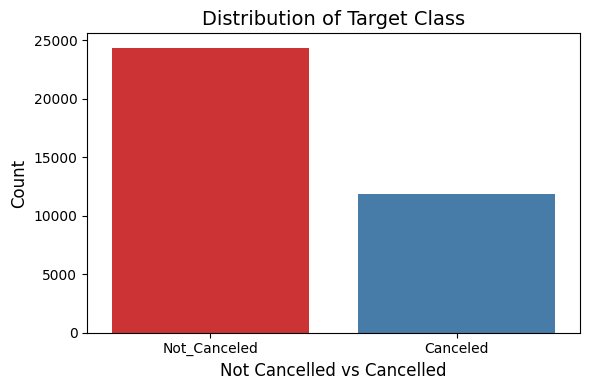

In [ ]:
plt.figure(figsize = (6,4))
ax = sns.countplot(x = df['booking_status'], palette='Set1')
plt.title("Distribution of Target Class", fontsize = 14)
plt.xlabel("Not Cancelled vs Cancelled", fontsize = 12)
plt.ylabel("Count", fontsize = 12)

plt.tight_layout()
plt.show()

In [ ]:
# Drop unneeded ID/date columns
df = df.drop(columns=['Booking_ID', 'arrival_date'])

# Define categorical and numeric features
cat_features = [
     'type_of_meal_plan',
    'required_car_parking_space', 'room_type_reserved', 'arrival_month',
    'market_segment_type', 'repeated_guest', 'arrival_year'
]

num_features = [
    'lead_time', 'avg_price_per_room', 'no_of_special_requests',
    'no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights',
    'no_of_previous_bookings_not_canceled', 'no_of_previous_cancellations'
]

df['booking_status'] = df['booking_status'].map({'Canceled': 1, 'Not_Canceled': 0})

target = 'booking_status'

# Encode categorical features
df_encoded = pd.get_dummies(df[cat_features], drop_first=True)

#Scale numeric features
scaler = StandardScaler()
df[num_features] = scaler.fit_transform(df[num_features])

# Combine scaled numerics + encoded categoricals + target
df_final = pd.concat([df[num_features], df_encoded, df[target]], axis=1)

# Define X and y
X = df_final.drop(columns=[target])
y = df_final[target]


<Axes: >

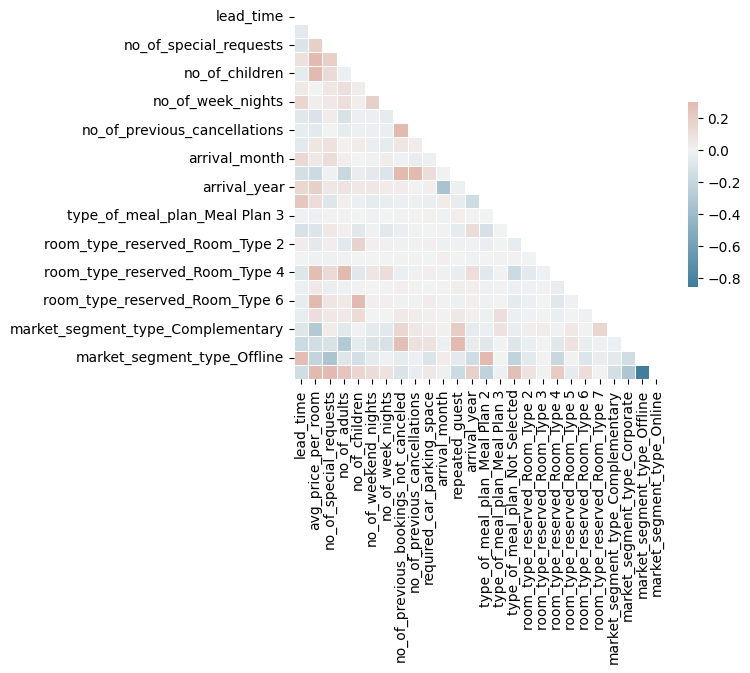

In [ ]:
# Check correlation
mask = np.triu(np.ones_like(X.corr(), dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(X.corr(), mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

## 4. Model Definition and Training (Fit)

In [ ]:
# Helper function for evaluation with K-Fold
def evaluate_with_kfold(model, X, y, label=""):
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    f1 = make_scorer(f1_score, pos_label=1)
    precision = make_scorer(precision_score, pos_label=1)
    accuracy = make_scorer(accuracy_score)

    # F1 and AUC cross-validation
    precision_scores = cross_val_score(model, X, y, cv=kf, scoring=precision)
    accuracy_scores = cross_val_score(model, X, y, cv=kf, scoring=accuracy)
    f1_scores = cross_val_score(model, X, y, cv=kf, scoring=f1)
    auc_scores = cross_val_score(model, X, y, cv=kf, scoring='roc_auc')

    print(f"---- {label} ----")
    print(f"Mean Accuracy (5-fold):  {accuracy_scores.mean():.3f} ± {accuracy_scores.std():.3f}")
    print(f"Mean Precision (5-fold): {precision_scores.mean():.3f} ± {precision_scores.std():.3f}")
    print(f"Mean F1-score (5-fold): {f1_scores.mean():.3f} ± {f1_scores.std():.3f}")
    print(f"Mean AUC (5-fold)     : {auc_scores.mean():.3f} ± {auc_scores.std():.3f}")
    print()

    return {
        "Model": label,
        "Accuracy_mean": accuracy_scores.mean(),
        "Precision_mean": precision_scores.mean(),
        "F1_mean": f1_scores.mean(),
        "AUC_mean": auc_scores.mean()
    }


In [ ]:
#Confusion Matrix Function for Models
def plot_conf_matrix(model, X, y, title, color):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    y_preds = []
    y_tests = []
    for train_idx, test_idx in skf.split(X, y):
        model.fit(X.iloc[train_idx], y.iloc[train_idx])
        y_pred = model.predict(X.iloc[test_idx])
        y_preds.extend(y_pred)
        y_tests.extend(y.iloc[test_idx])
    cm = confusion_matrix(y_tests, y_preds)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap=color)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()


---- Model 1: Baseline Logistic Regression ----
Mean Accuracy (5-fold):  0.802 ± 0.003
Mean Precision (5-fold): 0.734 ± 0.004
Mean F1-score (5-fold): 0.672 ± 0.008
Mean AUC (5-fold)     : 0.861 ± 0.004



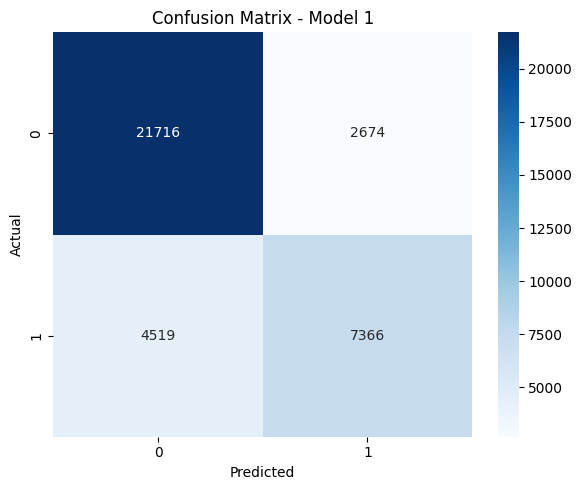

In [ ]:
#Model 1 - Baseline Logistic Regression
model1 = LogisticRegression(max_iter=5000, solver='liblinear')
results = []
results.append(evaluate_with_kfold(model1, X, y, "Model 1: Baseline Logistic Regression"))
plot_conf_matrix(model1, X, y, "Confusion Matrix - Model 1", "Blues")


---- Model 2: LASSO Logistic Regression ----
Mean Accuracy (5-fold):  0.802 ± 0.003
Mean Precision (5-fold): 0.733 ± 0.004
Mean F1-score (5-fold): 0.675 ± 0.009
Mean AUC (5-fold)     : 0.862 ± 0.004



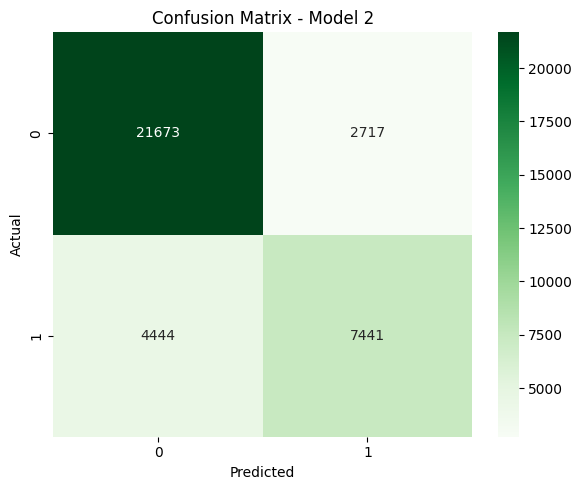

In [ ]:
#Model 2 - LASSO (L1-Regularization) Logistic Regression
model2 = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, max_iter=5000)
results.append(evaluate_with_kfold(model2, X, y, "Model 2: LASSO Logistic Regression"))
plot_conf_matrix(model2, X, y, "Confusion Matrix - Model 2", 'Greens')

### Feature Engineering

---- Model 3: Feature-Engineered Logistic ----
Mean Accuracy (5-fold):  0.801 ± 0.003
Mean Precision (5-fold): 0.728 ± 0.003
Mean F1-score (5-fold): 0.672 ± 0.009
Mean AUC (5-fold)     : 0.861 ± 0.003



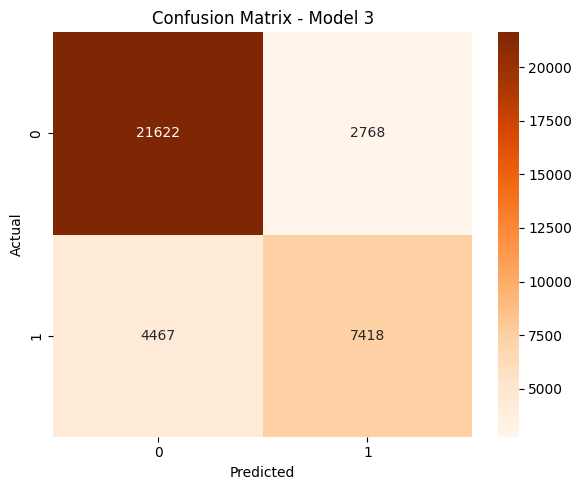

In [ ]:
#Model 3 - Logistic Regression with Engineered Features
df_final['price_per_guest'] = df['avg_price_per_room'] / (df['no_of_adults'] + df['no_of_children'] + 1)
df_final['lead_time_squared'] = df['lead_time'] ** 2
df_final['weekend_ratio'] = df['no_of_weekend_nights'] / (df['no_of_week_nights'] + 1)
df_final['family_size'] = df['no_of_adults'] + df['no_of_children']

X = df_final.drop(columns=target)
y = df_final[target]

# ---------------------------------------
model3 = LogisticRegression(max_iter=5000, solver='liblinear')
results.append(evaluate_with_kfold(model3, X, y, "Model 3: Feature-Engineered Logistic"))
plot_conf_matrix(model3, X, y, "Confusion Matrix - Model 3", 'Oranges')

---- Model 4: LASSO + Engineered Features ----
Mean Accuracy (5-fold):  0.802 ± 0.002
Mean Precision (5-fold): 0.727 ± 0.003
Mean F1-score (5-fold): 0.676 ± 0.008
Mean AUC (5-fold)     : 0.863 ± 0.003



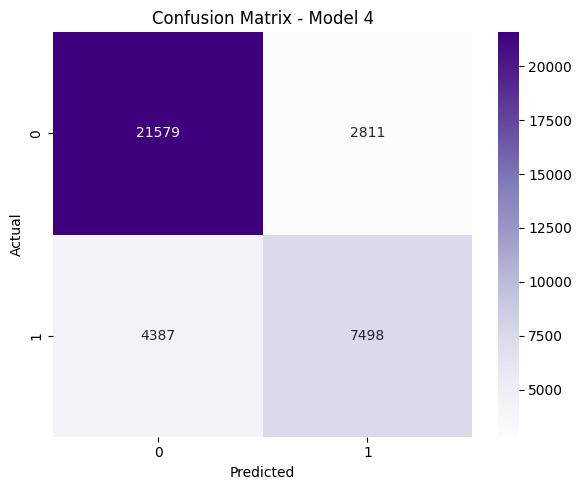

In [ ]:
#Model 4 - Lasso + Engineered Features
model4 = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, max_iter=5000)
results.append(evaluate_with_kfold(model4, X, y, "Model 4: LASSO + Engineered Features"))
plot_conf_matrix(model4, X, y, "Confusion Matrix - Model 4", 'Purples')

##5. Results and Model Evaluation

In [ ]:
results_df = pd.DataFrame(results)
results_df.sort_values(by="AUC_mean", ascending=True)

,Model,Accuracy_mean,Precision_mean,F1_mean,AUC_mean
0,Model 1: Baseline Logistic Regression,0.801709,0.733771,0.671814,0.861036
2,Model 3: Feature-Engineered Logistic,0.800551,0.728342,0.672063,0.861416
1,Model 2: LASSO Logistic Regression,0.802398,0.732713,0.674503,0.862226
3,Model 4: LASSO + Engineered Features,0.801626,0.727299,0.675570,0.863091


In [ ]:
def auc_score_cv(model, X, y):
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    auc_scores = cross_val_score(model, X, y, cv=kf, scoring='roc_auc')
    return auc_scores.mean()

# Forward Selection on MODEL3
remaining_features = list(X.columns)
selected_features = []
best_auc = 0

print("Forward Selection")
while remaining_features:
    auc_with_candidates = []
    for f in remaining_features:
        trial_features = selected_features + [f]
        model = LogisticRegression(max_iter=5000, solver='liblinear')
        auc = auc_score_cv(model, X[trial_features], y)
        auc_with_candidates.append((auc, f))

    auc_with_candidates.sort(reverse=True)  # best first
    best_new_auc, best_feature = auc_with_candidates[0]

    if best_new_auc > best_auc:
        selected_features.append(best_feature)
        remaining_features.remove(best_feature)
        best_auc = best_new_auc
        print(f"Added: {best_feature:30s}  AUC = {best_auc:.4f}")
    else:
        break

print("\nForward Features:", selected_features, "\n")

Forward Selection
Added: lead_time                       AUC = 0.7572
Added: no_of_special_requests          AUC = 0.7969
Added: market_segment_type_Online      AUC = 0.8443
Added: avg_price_per_room              AUC = 0.8541
Added: required_car_parking_space      AUC = 0.8566
Added: market_segment_type_Offline     AUC = 0.8577
Added: no_of_weekend_nights            AUC = 0.8588
Added: arrival_month                   AUC = 0.8597
Added: lead_time_squared               AUC = 0.8603
Added: type_of_meal_plan_Not Selected  AUC = 0.8611
Added: repeated_guest                  AUC = 0.8616
Added: room_type_reserved_Room_Type 6  AUC = 0.8620
Added: room_type_reserved_Room_Type 7  AUC = 0.8623
Added: room_type_reserved_Room_Type 5  AUC = 0.8624
Added: market_segment_type_Corporate   AUC = 0.8625
Added: market_segment_type_Complementary  AUC = 0.8627
Added: room_type_reserved_Room_Type 2  AUC = 0.8628
Added: room_type_reserved_Room_Type 4  AUC = 0.8629
Added: no_of_previous_cancellations    AUC 

In [ ]:
remaining_features = list(X.columns)
model = LogisticRegression(max_iter=5000, solver='liblinear')
best_auc = auc_score_cv(model, X[remaining_features], y)

#Backward Selection on MODEL3
print("Backward Selection")
improved = True
while improved and len(remaining_features) > 1:
    auc_without_candidates = []
    for f in remaining_features:
        trial_features = [x for x in remaining_features if x != f]
        model = LogisticRegression(max_iter=5000, solver='liblinear')
        auc = auc_score_cv(model, X[trial_features], y)
        auc_without_candidates.append((auc, f))

    auc_without_candidates.sort(reverse=True)
    best_new_auc, removed_feature = auc_without_candidates[0]

    if best_new_auc >= best_auc:
        remaining_features.remove(removed_feature)
        best_auc = best_new_auc
        print(f"Removed: {removed_feature:30s}  AUC = {best_auc:.4f}")
    else:
        improved = False

print("\nBackward Features:", remaining_features)

Backward Selection
Removed: arrival_year                    AUC = 0.8630
Removed: weekend_ratio                   AUC = 0.8631
Removed: market_segment_type_Online      AUC = 0.8631
Removed: price_per_guest                 AUC = 0.8631
Removed: no_of_previous_bookings_not_canceled  AUC = 0.8631
Removed: no_of_adults                    AUC = 0.8631
Removed: family_size                     AUC = 0.8631
Removed: room_type_reserved_Room_Type 3  AUC = 0.8631
Removed: type_of_meal_plan_Meal Plan 3   AUC = 0.8631

Backward Features: ['lead_time', 'avg_price_per_room', 'no_of_special_requests', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights', 'no_of_previous_cancellations', 'required_car_parking_space', 'arrival_month', 'repeated_guest', 'type_of_meal_plan_Meal Plan 2', 'type_of_meal_plan_Not Selected', 'room_type_reserved_Room_Type 2', 'room_type_reserved_Room_Type 4', 'room_type_reserved_Room_Type 5', 'room_type_reserved_Room_Type 6', 'room_type_reserved_Room_Type 7', 'market_se

In [ ]:
#Comparison Chart
results_df = pd.DataFrame(results)

# Evaluate Forward Selection Model
model_forward = LogisticRegression(max_iter=5000, solver='liblinear')
X_forward = X[selected_features]
results.append(evaluate_with_kfold(model_forward, X_forward, y, "Model 5: Forward Selection Logistic"))

# Evaluate Backward Selection Model
model_backward = LogisticRegression(max_iter=5000, solver='liblinear')
X_backward = X[remaining_features]
results.append(evaluate_with_kfold(model_backward, X_backward, y, "Model 6: Backward Selection Logistic"))


results_df = pd.DataFrame(results)
results_df.sort_values(by="AUC_mean", ascending=True)

---- Model 5: Forward Selection Logistic ----
Mean Accuracy (5-fold):  0.801 ± 0.002
Mean Precision (5-fold): 0.728 ± 0.002
Mean F1-score (5-fold): 0.675 ± 0.008
Mean AUC (5-fold)     : 0.863 ± 0.003

---- Model 6: Backward Selection Logistic ----
Mean Accuracy (5-fold):  0.801 ± 0.002
Mean Precision (5-fold): 0.727 ± 0.003
Mean F1-score (5-fold): 0.675 ± 0.008
Mean AUC (5-fold)     : 0.863 ± 0.003



,Model,Accuracy_mean,Precision_mean,F1_mean,AUC_mean
0,Model 1: Baseline Logistic Regression,0.801709,0.733771,0.671814,0.861036
2,Model 3: Feature-Engineered Logistic,0.800551,0.728342,0.672063,0.861416
1,Model 2: LASSO Logistic Regression,0.802398,0.732713,0.674503,0.862226
3,Model 4: LASSO + Engineered Features,0.801626,0.727299,0.675570,0.863091
4,Model 5: Forward Selection Logistic,0.801351,0.727526,0.674864,0.863108
5,Model 6: Backward Selection Logistic,0.801185,0.727328,0.674541,0.863126
